# ﾎﾞｰﾙﾄﾞｼﾞｪﾙ SoV Analysis — Multi-Period Comparison

**Purpose:** Track Share of Voice (SoV) change for ﾎﾞｰﾙﾄﾞｼﾞｪﾙ across three periods to evaluate pricing success in capturing shopper share from competitors.

**Definition:** SoV = Sub-brands purchased during the pre-period by shoppers who bought ﾎﾞｰﾙﾄﾞｼﾞｪﾙ in the target (post) period.

| Period | Post Window | Pre Window (2M) |
|---|---|---|
| Current | 2026-02-09 → 2026-02-28 | 2025-12-09 → 2026-02-08 |
| P3M | 2025-11-01 → 2026-01-31 | 2025-09-01 → 2025-10-31 |
| P6M | 2025-06-01 → 2025-10-31 | 2025-04-01 → 2025-05-31 |

**Target brand:** ﾎﾞｰﾙﾄﾞｼﾞｪﾙ (`jp_sub_brand_alter_lang_name`)  
**Competitor scope:** 洗濯洗剤 sub-category  
**Retailer filter:** All (no restriction)  
**Created:** 2026-02-18

---
## 0. Imports & Connection Setup

In [15]:
import os
import pandas as pd
import warnings
from datetime import datetime
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.font_manager as fm
import numpy as np
from dotenv import load_dotenv
import databricks.sql as sql

warnings.filterwarnings('ignore')
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda x: f'{x:,.1f}')

# ── Japanese font setup (fix 文字化け) ────────────────────────────────────
def _find_japanese_font() -> str | None:
    """Return the first available Japanese-capable font name, or None."""
    candidates = [
        'MS Gothic', 'MS PGothic', 'Yu Gothic', 'Meiryo',
        'IPAexGothic', 'IPAGothic', 'Noto Sans CJK JP',
        'Hiragino Sans', 'Hiragino Kaku Gothic Pro',
    ]
    available = {f.name for f in fm.fontManager.ttflist}
    for name in candidates:
        if name in available:
            return name
    return None

_jp_font = _find_japanese_font()
if _jp_font:
    plt.rcParams['font.family'] = _jp_font
    print(f'✅ Japanese font set: {_jp_font}')
else:
    print('⚠️  No Japanese font found — labels may show □. '
          'Install MS Gothic / IPAexGothic / Noto Sans CJK JP')

# Load Databricks credentials from .env
load_dotenv(dotenv_path='../../.env')
DATABRICKS_HOST      = os.getenv('DATABRICKS_HOST')
DATABRICKS_TOKEN     = os.getenv('DATABRICKS_TOKEN')
DATABRICKS_HTTP_PATH = os.getenv('DATABRICKS_HTTP_PATH')

assert DATABRICKS_HOST,      'DATABRICKS_HOST not set in .env'
assert DATABRICKS_TOKEN,     'DATABRICKS_TOKEN not set in .env'
assert DATABRICKS_HTTP_PATH, 'DATABRICKS_HTTP_PATH not set in .env'
print('✅ Credentials loaded successfully')

# ── Reusable query helper ──────────────────────────────────────────────────
def execute_query(query: str) -> pd.DataFrame:
    """Execute a SQL query against Databricks and return a DataFrame."""
    with sql.connect(
        server_hostname=DATABRICKS_HOST,
        http_path=DATABRICKS_HTTP_PATH,
        access_token=DATABRICKS_TOKEN
    ) as connection:
        with connection.cursor() as cursor:
            cursor.execute(query)
            result  = cursor.fetchall()
            columns = [desc[0] for desc in cursor.description]
            return pd.DataFrame(result, columns=columns)


✅ Japanese font set: MS Gothic
✅ Credentials loaded successfully


---
## 1. Analysis Parameters

In [16]:
# ── Target definition ─────────────────────────────────────────────────────
TARGET_SUB_BRAND       = 'ﾎﾞｰﾙﾄﾞｼﾞｪﾙ'
SUB_CATEGORY_FILTER    = '洗濯洗剤'
SOV_GRANULARITY_1      = 'jp_brand_alter_lang_name'
SOV_GRANULARITY_2      = 'jp_sub_brand_alter_lang_name'

# ── Period windows ────────────────────────────────────────────────────────
# pre_period = 2 months immediately before each post_start_date
PERIODS = {
    'Current': {
        'post_start': '2026-02-09',
        'post_end':   '2026-02-28',
        'pre_start':  '2025-12-09',
        'pre_end':    '2026-02-08',
    },
    'P3M': {
        'post_start': '2025-11-01',
        'post_end':   '2026-01-31',
        'pre_start':  '2025-09-01',
        'pre_end':    '2025-10-31',
    },
    'P6M': {
        'post_start': '2025-06-01',
        'post_end':   '2025-10-31',
        'pre_start':  '2025-04-01',
        'pre_end':    '2025-05-31',
    },
}

print('📋 Analysis Parameters')
print(f'  Target sub-brand  : {TARGET_SUB_BRAND}')
print(f'  Sub-category scope: {SUB_CATEGORY_FILTER}')
print(f'  SoV granularity   : {SOV_GRANULARITY_1} → {SOV_GRANULARITY_2}')
print()
for period, dates in PERIODS.items():
    print(f'  [{period}]')
    print(f'    Post : {dates["post_start"]} → {dates["post_end"]}')
    print(f'    Pre  : {dates["pre_start"]}  → {dates["pre_end"]}')

📋 Analysis Parameters
  Target sub-brand  : ﾎﾞｰﾙﾄﾞｼﾞｪﾙ
  Sub-category scope: 洗濯洗剤
  SoV granularity   : jp_brand_alter_lang_name → jp_sub_brand_alter_lang_name

  [Current]
    Post : 2026-02-09 → 2026-02-28
    Pre  : 2025-12-09  → 2026-02-08
  [P3M]
    Post : 2025-11-01 → 2026-01-31
    Pre  : 2025-09-01  → 2025-10-31
  [P6M]
    Post : 2025-06-01 → 2025-10-31
    Pre  : 2025-04-01  → 2025-05-31


In [25]:

# ── Data availability check ────────────────────────────────────────────────
# Check latest available date and daily buyer counts for ﾎﾞｰﾙﾄﾞｼﾞｪﾙ
# to determine how much Current-period data we actually have
data_avail_query = f"""
SELECT
    CAST(idpos.sales_period_group_end_date_part AS DATE) AS purchase_date,
    COUNT(DISTINCT idpos.shopper_key)                    AS daily_buyers
FROM cdl_customer_prod.gold_customer_loyalty.loyalty_transact_fct_v1_vw idpos
LEFT JOIN id_pos_ai_1.prod_dim_ext_vw prod
       ON idpos.prod_key = prod.prod_key
LEFT JOIN id_pos_ai_1.shopper_dim_generic_vw shopper
       ON idpos.shopper_key = shopper.shopper_key
WHERE prod.jp_sub_brand_alter_lang_name = '{TARGET_SUB_BRAND}'
  AND prod.jp_sub_category_alter_lang_name = '{SUB_CATEGORY_FILTER}'
  AND idpos.sales_period_group_end_date_part BETWEEN '2025-12-01' AND '2026-02-28'
  AND shopper.member_ind = 'Y'
GROUP BY 1
ORDER BY 1
"""

print('⏳ Checking data availability...', end=' ', flush=True)
df_avail = execute_query(data_avail_query)
df_avail['purchase_date'] = pd.to_datetime(df_avail['purchase_date'])
df_avail['daily_buyers']  = pd.to_numeric(df_avail['daily_buyers'])
print('done')

latest_date   = df_avail['purchase_date'].max()
earliest_date = df_avail['purchase_date'].min()

print(f'\n📅 Data range : {earliest_date.date()} → {latest_date.date()}')
print(f'   Latest date : {latest_date.date()}')
print(f'   Days available since Feb 9 (discount start): '
      f'{(latest_date - pd.Timestamp("2026-02-09")).days + 1} days')
print()

# Show daily buyers per week to gauge completeness
df_avail['week'] = df_avail['purchase_date'].dt.to_period('W')
weekly = df_avail.groupby('week')['daily_buyers'].agg(['sum','mean','count']).rename(
    columns={'sum':'weekly_buyers','mean':'avg_daily','count':'days_with_data'})
print('Weekly buyer summary (ﾎﾞｰﾙﾄﾞｼﾞｪﾙ, Dec 2025–Feb 2026):')
print(weekly.tail(12).to_string())


⏳ Checking data availability... done

📅 Data range : 2025-12-01 → 2026-02-18
   Latest date : 2026-02-18
   Days available since Feb 9 (discount start): 10 days

Weekly buyer summary (ﾎﾞｰﾙﾄﾞｼﾞｪﾙ, Dec 2025–Feb 2026):
                       weekly_buyers  avg_daily  days_with_data
week                                                           
2025-12-01/2025-12-07          55847    7,978.1               7
2025-12-08/2025-12-14          55377    7,911.0               7
2025-12-15/2025-12-21          66136    9,448.0               7
2025-12-22/2025-12-28          74227   10,603.9               7
2025-12-29/2026-01-04          60404    8,629.1               7
2026-01-05/2026-01-11          77800   11,114.3               7
2026-01-12/2026-01-18          73436   10,490.9               7
2026-01-19/2026-01-25          60328    8,618.3               7
2026-01-26/2026-02-01          56247    8,035.3               7
2026-02-02/2026-02-08          43786    6,255.1               7
2026-02-09/2026-

---
## 2. Data Quality Check — Product Master Validation

Confirms that the target sub-brand exists in the product dimension and lists discovered GTINs / product names before running the main SoV queries.

In [17]:
print('=' * 65)
print('DQ-1: Product Master Existence Check')
print('=' * 65)

product_check_query = f"""
SELECT DISTINCT
    jp_item_gtin,
    jp_prod_alter_lang_name,
    jp_sub_brand_alter_lang_name,
    jp_brand_alter_lang_name,
    jp_sub_category_alter_lang_name,
    jp_prod_form_name
FROM id_pos_ai_1.prod_dim_ext_vw
WHERE jp_sub_brand_alter_lang_name = '{TARGET_SUB_BRAND}'
  AND jp_sub_category_alter_lang_name = '{SUB_CATEGORY_FILTER}'
ORDER BY jp_item_gtin
"""

df_products = execute_query(product_check_query)

print(f'  Rows found       : {len(df_products):,}')
print(f'  Unique GTINs     : {df_products["jp_item_gtin"].nunique():,}')
print(f'  Unique prod names: {df_products["jp_prod_alter_lang_name"].nunique():,}')
print()

# ── ASSERTION ─────────────────────────────────────────────────────────────
assert len(df_products) > 0, (
    f"❌ FAIL: No products found for sub_brand='{TARGET_SUB_BRAND}' "
    f"AND sub_category='{SUB_CATEGORY_FILTER}'. Check spelling of filter values."
)
print('✅ PASS: Target sub-brand exists in product master')
print()
print('Product detail:')
display(df_products)

DQ-1: Product Master Existence Check
  Rows found       : 455
  Unique GTINs     : 422
  Unique prod names: 397

✅ PASS: Target sub-brand exists in product master

Product detail:


,jp_item_gtin,jp_prod_alter_lang_name,jp_sub_brand_alter_lang_name,jp_brand_alter_lang_name,jp_sub_category_alter_lang_name,jp_prod_form_name
0,00000000079198,ﾎﾞｰﾙﾄﾞ ｼﾞｪﾙ ﾐｭｹﾞ 詰替 SSL,ﾎﾞｰﾙﾄﾞｼﾞｪﾙ,ﾎﾞｰﾙﾄﾞ,洗濯洗剤,液体非濃縮
1,00405020000458,ﾎﾞｰﾙﾄﾞ ｼﾞｪﾙ ｹｰｽ,ﾎﾞｰﾙﾄﾞｼﾞｪﾙ,ﾎﾞｰﾙﾄﾞ,洗濯洗剤,液体非濃縮
2,00405020000465,ﾎﾞｰﾙﾄﾞ ｼﾞｪﾙ ｹｰｽ販売,ﾎﾞｰﾙﾄﾞｼﾞｪﾙ,ﾎﾞｰﾙﾄﾞ,洗濯洗剤,液体非濃縮
3,00405020000533,ﾎﾞｰﾙﾄﾞ ｼﾞｪﾙ S 詰替 超特大,ﾎﾞｰﾙﾄﾞｼﾞｪﾙ,ﾎﾞｰﾙﾄﾞ,洗濯洗剤,液体非濃縮
4,00405020000540,ﾎﾞｰﾙﾄﾞ ｼﾞｪﾙ B 詰替 超特大,ﾎﾞｰﾙﾄﾞｼﾞｪﾙ,ﾎﾞｰﾙﾄﾞ,洗濯洗剤,液体非濃縮
...,...,...,...,...,...,...
450,04987176349712,ﾎﾞｰﾙﾄﾞｼﾞｪﾙｻｸﾗﾌﾛｰﾗﾙﾉ香ﾘ 詰替用 ｳﾙﾄﾗｼﾞｬﾝﾎﾞｻｲｽﾞ 1400g,ﾎﾞｰﾙﾄﾞｼﾞｪﾙ,ﾎﾞｰﾙﾄﾞ,洗濯洗剤,液体非濃縮
451,04987176389695,ﾎﾞｰﾙﾄﾞｼﾞｪﾙ ﾎﾜｲﾄﾑｽｸﾉ香ﾘ 本体 610g,ﾎﾞｰﾙﾄﾞｼﾞｪﾙ,ﾎﾞｰﾙﾄﾞ,洗濯洗剤,液体非濃縮
452,04987176389718,ﾎﾞｰﾙﾄﾞｼﾞｪﾙ ﾎﾜｲﾄﾑｽｸﾉ香ﾘ 詰替用 超特大ｻｲｽﾞ 630g,ﾎﾞｰﾙﾄﾞｼﾞｪﾙ,ﾎﾞｰﾙﾄﾞ,洗濯洗剤,液体非濃縮
453,04987176389732,ﾎﾞｰﾙﾄﾞｼﾞｪﾙ ﾎﾜｲﾄﾑｽｸﾉ香ﾘ 詰替用 ｳﾙﾄﾗｼﾞｬﾝﾎﾞｻｲｽﾞ 1400g,ﾎﾞｰﾙﾄﾞｼﾞｪﾙ,ﾎﾞｰﾙﾄﾞ,洗濯洗剤,液体非濃縮


---
## 3. SoV Query Builder

In [18]:
def build_sov_query(
    pre_start: str,
    pre_end: str,
    post_start: str,
    post_end: str,
    target_sub_brand: str,
    sub_category: str,
    granularity_1: str,
    granularity_2: str,
) -> str:
    """
    Build the parameterized SoV SQL.
    Logic:
      base  = all 洗濯洗剤 purchases spanning pre+post range
      pre   = sub-brand purchases in pre window (source brands)
      post  = DISTINCT shopper_keys who bought target in post window

      Matched leg  : INNER JOIN post × pre → GROUP BY ROLLUP(g1, g2)
                     ROLLUP produces: sub-brand rows, brand subtotals (g2=NULL),
                     and grand total (g1=NULL, g2=NULL).
                     NVL is NOT used here so ROLLUP NULLs stay as real NULLs.

      NTC leg      : LEFT JOIN post × pre WHERE t2.id IS NULL
                     → exactly one row with g1=NULL, g2='New to Category'

      Separating the two legs avoids the original bug where NVL converted
      ROLLUP brand-subtotal NULLs (g2=NULL) into 'New to Category', producing
      a spurious NTC row for every brand in the data.
    """
    return f"""
WITH base AS (
    SELECT
        prod.{granularity_1}                                          AS g1,
        prod.{granularity_2}                                          AS g2,
        prod.jp_sub_brand_alter_lang_name,
        idpos.shopper_key                                             AS id,
        idpos.pos_unit_sales_qty                                      AS unit,
        idpos.pos_sales_amt                                           AS value,
        CAST(idpos.sales_period_group_end_date_part AS DATE)          AS purchase_date
    FROM cdl_customer_prod.gold_customer_loyalty.loyalty_transact_fct_v1_vw idpos
    LEFT JOIN id_pos_ai_1.prod_dim_ext_vw prod
           ON idpos.prod_key = prod.prod_key
    LEFT JOIN id_pos_ai_1.shopper_dim_generic_vw shopper
           ON idpos.shopper_key = shopper.shopper_key
    WHERE prod.jp_sub_category_alter_lang_name = '{sub_category}'
      AND idpos.sales_period_group_end_date_part
              BETWEEN '{pre_start}' AND '{post_end}'
      AND shopper.member_ind = 'Y'
),

pre AS (
    SELECT g1, g2, id, value, unit
    FROM base
    WHERE purchase_date BETWEEN '{pre_start}' AND '{pre_end}'
),

post AS (
    SELECT DISTINCT id
    FROM base
    WHERE jp_sub_brand_alter_lang_name = '{target_sub_brand}'
      AND purchase_date BETWEEN '{post_start}' AND '{post_end}'
)

-- Row 0: denominator – total post-period purchasers
SELECT
    'Post All'             AS sov_granularity_1,
    'Post All'             AS sov_granularity_2,
    COUNT(DISTINCT id)     AS SoV_ID,
    CAST(NULL AS DOUBLE)   AS SoV_Value,
    CAST(NULL AS DOUBLE)   AS SoV_Unit
FROM post

UNION ALL

-- Rows 1+: matched pre-period purchases (INNER JOIN keeps only matched buyers)
-- ROLLUP produces: sub-brand detail, brand subtotals (g2=NULL), grand total (g1=NULL, g2=NULL)
-- No NVL here — ROLLUP NULLs are left as NULL so they are filterable in Python
SELECT
    t2.g1                          AS sov_granularity_1,
    t2.g2                          AS sov_granularity_2,
    COUNT(DISTINCT t2.id)          AS SoV_ID,
    ROUND(SUM(t2.value), 0)        AS SoV_Value,
    ROUND(SUM(t2.unit),  0)        AS SoV_Unit
FROM post AS t1
JOIN pre AS t2 ON t1.id = t2.id
GROUP BY ROLLUP(t2.g1, t2.g2)

UNION ALL

-- NTC row: exactly one row for buyers with NO pre-period laundry purchase
-- g1=NULL (no brand), g2='New to Category' — distinguishable from ROLLUP NULLs
SELECT
    CAST(NULL AS STRING)           AS sov_granularity_1,
    'New to Category'              AS sov_granularity_2,
    COUNT(DISTINCT t1.id)          AS SoV_ID,
    CAST(0 AS DOUBLE)              AS SoV_Value,
    CAST(0 AS DOUBLE)              AS SoV_Unit
FROM post AS t1
LEFT JOIN pre AS t2 ON t1.id = t2.id
WHERE t2.id IS NULL

ORDER BY SoV_ID DESC
"""


---
## 4. Run SoV Queries for All Periods

In [19]:
raw_results = {}  # stores raw DataFrames keyed by period name

for period_name, dates in PERIODS.items():
    print(f'⏳ Running SoV query: [{period_name}] ...', end=' ', flush=True)
    query = build_sov_query(
        pre_start        = dates['pre_start'],
        pre_end          = dates['pre_end'],
        post_start       = dates['post_start'],
        post_end         = dates['post_end'],
        target_sub_brand = TARGET_SUB_BRAND,
        sub_category     = SUB_CATEGORY_FILTER,
        granularity_1    = SOV_GRANULARITY_1,
        granularity_2    = SOV_GRANULARITY_2,
    )
    df = execute_query(query)
    raw_results[period_name] = df
    print(f'done  ({len(df)} rows)')

print('\n✅ All queries completed.')

⏳ Running SoV query: [Current] ... done  (81 rows)
⏳ Running SoV query: [P3M] ... done  (106 rows)
⏳ Running SoV query: [P6M] ... done  (110 rows)

✅ All queries completed.


---
## 5. Data Quality Checks — Post-Query Validation

Checks performed per period:
- Row count > 0
- Type coercion and null audit
- Post-period buyer count > 0
- Pre-period match rate (≥ 20% expected)
- `pct_of_value` sums to ≈ 100% for matched buyers
- SoV_Value per-shopper ceiling check (outlier guard)

In [20]:
def run_dq_checks(df: pd.DataFrame, period_name: str) -> dict:
    """
    Run data quality checks on a raw SoV result DataFrame.
    Returns a dict of check results and the extracted total_post_buyers.
    """
    sep  = '=' * 65
    pass_ = '  ✅ PASS'
    fail_ = '  ❌ FAIL'
    warn_ = '  ⚠️  WARN'

    print(sep)
    print(f'DQ Checks: [{period_name}]')
    print(sep)

    # ── DQ-1: Row count > 0 ───────────────────────────────────────────────
    total_rows = len(df)
    if total_rows > 0:
        print(f'{pass_} DQ-1: Rows returned = {total_rows:,}')
    else:
        print(f'{fail_} DQ-1: Query returned 0 rows — check period dates and filters')
        assert False, f'[{period_name}] SoV query returned 0 rows'

    # ── DQ-2: Type coercion ───────────────────────────────────────────────
    df['SoV_ID']    = pd.to_numeric(df['SoV_ID'],    errors='coerce').astype('Int64')
    df['SoV_Value'] = pd.to_numeric(df['SoV_Value'], errors='coerce')
    df['SoV_Unit']  = pd.to_numeric(df['SoV_Unit'],  errors='coerce')
    coerce_failures = df[['SoV_ID','SoV_Value','SoV_Unit']].isnull().sum()
    # SoV_Value and SoV_Unit are intentionally NULL for 'Post All' row — exclude
    detail_nulls = df[df['sov_granularity_1'] != 'Post All'][['SoV_ID','SoV_Value','SoV_Unit']].isnull().sum()
    if detail_nulls.sum() == 0:
        print(f'{pass_} DQ-2: No unexpected nulls in numeric columns')
    else:
        print(f'{warn_} DQ-2: Unexpected nulls in detail rows:')
        print(detail_nulls[detail_nulls > 0].to_string())

    # ── DQ-3: Total post buyers > 0 ───────────────────────────────────────
    post_all_mask     = df['sov_granularity_1'] == 'Post All'
    assert post_all_mask.sum() == 1, f'[{period_name}] Expected exactly 1 "Post All" row'
    total_post_buyers = int(df.loc[post_all_mask, 'SoV_ID'].iloc[0])
    if total_post_buyers > 0:
        print(f'{pass_} DQ-3: Total post-period buyers = {total_post_buyers:,}')
    else:
        print(f'{fail_} DQ-3: No post-period buyers found — no one bought {TARGET_SUB_BRAND} in this window')
        assert False, f'[{period_name}] total_post_buyers = 0'

    # ── DQ-4: Pre-period match rate ───────────────────────────────────────
    # TTL ROLLUP row = total distinct pre-period matched shoppers
    ttl_mask  = (
        (df['sov_granularity_1'] == 'TTL') |
        (
            df['sov_granularity_1'].notna() &
            df['sov_granularity_2'].isna() &
            (df['sov_granularity_1'] != 'Post All') &
            (df['sov_granularity_1'] != 'New to Category')
        )
    )
    # Grand total ROLLUP row has both g1 and g2 as NULL
    grand_ttl_mask = (
        df['sov_granularity_1'].isna() & df['sov_granularity_2'].isna()
    )
    new_to_cat_mask = df['sov_granularity_2'] == 'New to Category'

    matched_shoppers = 0
    if grand_ttl_mask.sum() > 0:
        matched_shoppers = int(df.loc[grand_ttl_mask, 'SoV_ID'].iloc[0])
    else:
        # Fall back: sum sub-brand level rows
        detail_df_tmp = df[
            ~post_all_mask & ~grand_ttl_mask & ~new_to_cat_mask &
            df['sov_granularity_2'].notna()
        ]
        matched_shoppers = detail_df_tmp['SoV_ID'].sum()

    match_rate = matched_shoppers / total_post_buyers * 100 if total_post_buyers > 0 else 0
    if match_rate >= 20:
        print(f'{pass_} DQ-4: Pre-period match rate = {match_rate:.1f}%  ({matched_shoppers:,} / {total_post_buyers:,})')
    elif match_rate > 0:
        print(f'{warn_} DQ-4: Low pre-period match rate = {match_rate:.1f}%  '
              f'({matched_shoppers:,} / {total_post_buyers:,}) — many shoppers are new to category')
    else:
        print(f'{warn_} DQ-4: Match rate = 0% — all post-period buyers are new to category')

    # ── DQ-5: pct_of_value sums to ≈ 100% for sub-brand rows ─────────────
    detail_mask = (
        ~post_all_mask &
        df['sov_granularity_2'].notna() &
        (df['sov_granularity_2'] != 'New to Category') &
        ~grand_ttl_mask
    )
    # Remove ROLLUP brand-subtotals (g2 == NULL)
    sub_brand_only_mask = detail_mask & df['sov_granularity_2'].notna()
    detail_value_df = df[sub_brand_only_mask].copy()

    total_value = detail_value_df['SoV_Value'].sum()
    if total_value > 0:
        detail_value_df['pct_of_value_check'] = detail_value_df['SoV_Value'] / total_value * 100
        pct_sum = detail_value_df['pct_of_value_check'].sum()
        if 99.0 <= pct_sum <= 101.0:
            print(f'{pass_} DQ-5: pct_of_value sums to {pct_sum:.2f}%  (target: ~100%)')
        else:
            print(f'{warn_} DQ-5: pct_of_value sums to {pct_sum:.2f}%  — may indicate duplicate rows')
    else:
        print(f'{warn_} DQ-5: SoV_Value total = 0 — no matched pre-period value found')

    # ── DQ-6: Per-shopper value ceiling (outlier guard) ───────────────────
    if total_value > 0 and total_post_buyers > 0:
        avg_value_per_buyer = total_value / total_post_buyers
        if avg_value_per_buyer < 500_000:  # ¥500k per buyer ceiling
            print(f'{pass_} DQ-6: Avg SoV_Value per post-buyer = ¥{avg_value_per_buyer:,.0f}  (within ¥500k ceiling)')
        else:
            print(f'{warn_} DQ-6: High avg value per buyer = ¥{avg_value_per_buyer:,.0f}  — check for outliers')

    print()
    return {'total_post_buyers': total_post_buyers, 'df': df}


# ── Run DQ checks for all periods ─────────────────────────────────────────
dq_results = {}
for period_name, df_raw in raw_results.items():
    dq_results[period_name] = run_dq_checks(df_raw.copy(), period_name)

DQ Checks: [Current]
  ✅ PASS DQ-1: Rows returned = 81
  ✅ PASS DQ-2: No unexpected nulls in numeric columns
  ✅ PASS DQ-3: Total post-period buyers = 57,925
  ✅ PASS DQ-4: Pre-period match rate = 67.5%  (39,115 / 57,925)
  ✅ PASS DQ-5: pct_of_value sums to 100.00%  (target: ~100%)
  ✅ PASS DQ-6: Avg SoV_Value per post-buyer = ¥14,600  (within ¥500k ceiling)

DQ Checks: [P3M]
  ✅ PASS DQ-1: Rows returned = 106
  ✅ PASS DQ-2: No unexpected nulls in numeric columns
  ✅ PASS DQ-3: Total post-period buyers = 519,649
  ✅ PASS DQ-4: Pre-period match rate = 56.8%  (295,215 / 519,649)
  ✅ PASS DQ-5: pct_of_value sums to 100.00%  (target: ~100%)
  ✅ PASS DQ-6: Avg SoV_Value per post-buyer = ¥2,527  (within ¥500k ceiling)

DQ Checks: [P6M]
  ✅ PASS DQ-1: Rows returned = 110
  ✅ PASS DQ-2: No unexpected nulls in numeric columns
  ✅ PASS DQ-3: Total post-period buyers = 796,490
  ✅ PASS DQ-4: Pre-period match rate = 51.1%  (406,890 / 796,490)
  ✅ PASS DQ-5: pct_of_value sums to 100.00%  (target: ~

---
## 6. SoV Results — Per-Period Tables

Sub-brand rows only (ROLLUP totals and Post All excluded). Sorted by shopper count descending.

In [21]:
def build_sov_table(df: pd.DataFrame, total_post_buyers: int, period_name: str) -> pd.DataFrame:
    """
    Clean the raw SoV DataFrame:
    - Keep sub-brand detail rows (g1 notna, g2 notna, not Post All, not NTC)
    - Append NTC row at bottom (g2 == 'New to Category', g1 set to '—')
    - ROLLUP subtotals (g1 notna, g2 isna) and grand total (g1 isna, g2 isna) are excluded
    - Add pct_of_post_buyers, pct_of_value, pct_of_units, avg_value_per_buyer

    NTC row characteristics after the SQL fix:
      g1 = NULL  (no brand — shopper had no pre-period purchase)
      g2 = 'New to Category'
      SoV_Value = 0, SoV_Unit = 0  (no pre-period spend to measure)
    """
    # Identify NTC: exactly one row where g2 == 'New to Category'
    ntc_mask = df['sov_granularity_2'] == 'New to Category'
    df_ntc   = df[ntc_mask].copy()

    # Sub-brand detail rows: g1 notna, g2 notna, not Post All, not NTC
    detail_mask = (
        (df['sov_granularity_1'] != 'Post All') &
        df['sov_granularity_1'].notna() &
        df['sov_granularity_2'].notna() &
        ~ntc_mask
    )
    df_detail = df[detail_mask].copy()

    # Compute shares (denominator = matched value/unit only, NTC excluded)
    total_value = df_detail['SoV_Value'].sum()
    total_unit  = df_detail['SoV_Unit'].sum()

    df_detail['pct_of_post_buyers'] = (df_detail['SoV_ID'] / total_post_buyers * 100).round(1)
    df_detail['pct_of_value']       = (df_detail['SoV_Value'] / total_value * 100).round(1) if total_value > 0 else 0
    df_detail['pct_of_units']       = (df_detail['SoV_Unit']  / total_unit  * 100).round(1) if total_unit  > 0 else 0
    df_detail['avg_value_per_buyer'] = (
        df_detail['SoV_Value'] / df_detail['SoV_ID'].replace(0, pd.NA)
    ).round(0)

    df_detail = df_detail.sort_values('SoV_ID', ascending=False).reset_index(drop=True)

    # Append NTC row at bottom
    if len(df_ntc) > 0:
        df_ntc['sov_granularity_1']   = '—'        # brand N/A for NTC
        df_ntc['pct_of_post_buyers']  = (df_ntc['SoV_ID'] / total_post_buyers * 100).round(1)
        df_ntc['pct_of_value']        = None        # no pre-period value to share
        df_ntc['pct_of_units']        = None
        df_ntc['avg_value_per_buyer'] = None
        df_detail = pd.concat([df_detail, df_ntc], ignore_index=True)

    df_detail.insert(0, 'period', period_name)
    df_detail.insert(1, 'total_post_buyers', total_post_buyers)
    return df_detail.rename(columns={
        'sov_granularity_1': 'brand',
        'sov_granularity_2': 'sub_brand',
    })


sov_tables = {}
for period_name in PERIODS:
    df_raw  = dq_results[period_name]['df']
    tpb     = dq_results[period_name]['total_post_buyers']
    sov_tables[period_name] = build_sov_table(df_raw, tpb, period_name)

    print(f'━━━ [{period_name}] SoV Table  (post-period buyers = {tpb:,}) ━━━')
    display(sov_tables[period_name][[
        'brand', 'sub_brand',
        'SoV_ID', 'pct_of_post_buyers',
        'SoV_Value', 'pct_of_value', 'avg_value_per_buyer',
        'SoV_Unit', 'pct_of_units',
    ]])
    print()


━━━ [Current] SoV Table  (post-period buyers = 57,925) ━━━


,brand,sub_brand,SoV_ID,pct_of_post_buyers,SoV_Value,pct_of_value,avg_value_per_buyer,SoV_Unit,pct_of_units
0,ﾎﾞｰﾙﾄﾞ,ﾎﾞｰﾙﾄﾞｼﾞｪﾙ,31842,55.0,"75,098,608.0",8.9,"2,358.0","132,560.0",11.3
1,ｱﾀｯｸ,ｱﾀｯｸ抗菌EX,3911,6.8,"167,280,518.0",19.8,"42,772.0","251,826.0",21.5
2,ﾆｭｰﾋﾞｰｽﾞ,ﾆｭｰﾋﾞｰｽﾞ ｼﾞｪﾙ,3785,6.5,"43,845,059.0",5.2,"11,584.0","80,423.0",6.9
3,ｱﾘｴｰﾙ,ｱﾘｴｰﾙｼﾞｪﾙ,2961,5.1,"84,408,201.0",10.0,"28,507.0","123,567.0",10.5
4,ﾎﾞｰﾙﾄﾞ,ﾎﾞｰﾙﾄﾞｼﾞｪﾙﾎﾞｰﾙ,2775,4.8,"93,390,798.0",11.0,"33,654.0","78,364.0",6.7
5,ｴﾏｰﾙ,ｴﾏｰﾙ,1749,3.0,"21,326,549.0",2.5,"12,194.0","45,090.0",3.8
6,ｱｸﾛﾝ,ｱｸﾛﾝ,1372,2.4,"14,422,498.0",1.7,"10,512.0","38,255.0",3.3
7,ｱﾀｯｸ,ｱﾀｯｸZERO,621,1.1,"80,616,312.0",9.5,"129,817.0","80,287.0",6.8
8,ﾅﾉｯｸｽ,ﾅﾉｯｸｽﾜﾝ,578,1.0,"47,647,204.0",5.6,"82,435.0","51,409.0",4.4
9,ｱﾘｴｰﾙ,ｱﾘｴｰﾙｼﾞｪﾙﾎﾞｰﾙ,541,0.9,"83,563,473.0",9.9,"154,461.0","62,117.0",5.3



━━━ [P3M] SoV Table  (post-period buyers = 519,649) ━━━


,brand,sub_brand,SoV_ID,pct_of_post_buyers,SoV_Value,pct_of_value,avg_value_per_buyer,SoV_Unit,pct_of_units
0,ﾎﾞｰﾙﾄﾞ,ﾎﾞｰﾙﾄﾞｼﾞｪﾙ,194619,37.5,"279,389,775.0",21.3,"1,436.0","498,224.0",24.8
1,ｱﾀｯｸ,ｱﾀｯｸ抗菌EX,51885,10.0,"253,457,761.0",19.3,"4,885.0","390,566.0",19.4
2,ｱﾘｴｰﾙ,ｱﾘｴｰﾙｼﾞｪﾙ,39323,7.6,"132,927,533.0",10.1,"3,380.0","218,801.0",10.9
3,ﾆｭｰﾋﾞｰｽﾞ,ﾆｭｰﾋﾞｰｽﾞ ｼﾞｪﾙ,30516,5.9,"62,055,024.0",4.7,"2,034.0","122,506.0",6.1
4,ﾎﾞｰﾙﾄﾞ,ﾎﾞｰﾙﾄﾞｼﾞｪﾙﾎﾞｰﾙ,29877,5.7,"128,255,281.0",9.8,"4,293.0","136,665.0",6.8
5,ｴﾏｰﾙ,ｴﾏｰﾙ,8164,1.6,"23,073,493.0",1.8,"2,826.0","50,101.0",2.5
6,ｱｸﾛﾝ,ｱｸﾛﾝ,7041,1.4,"15,033,880.0",1.1,"2,135.0","40,005.0",2.0
7,ﾅﾉｯｸｽ,ﾅﾉｯｸｽﾜﾝ,6154,1.2,"56,724,509.0",4.3,"9,218.0","67,441.0",3.4
8,ｱﾀｯｸ,ｱﾀｯｸZERO,5738,1.1,"91,218,219.0",6.9,"15,897.0","95,720.0",4.8
9,ｱﾘｴｰﾙ,ｱﾘｴｰﾙｼﾞｪﾙﾎﾞｰﾙ,5594,1.1,"96,954,407.0",7.4,"17,332.0","74,375.0",3.7



━━━ [P6M] SoV Table  (post-period buyers = 796,490) ━━━


,brand,sub_brand,SoV_ID,pct_of_post_buyers,SoV_Value,pct_of_value,avg_value_per_buyer,SoV_Unit,pct_of_units
0,ﾎﾞｰﾙﾄﾞ,ﾎﾞｰﾙﾄﾞｼﾞｪﾙ,212267,26.7,"294,016,496.0",21.6,"1,385.0","484,393.0",21.0
1,ｱﾘｴｰﾙ,ｱﾘｴｰﾙｼﾞｪﾙ,82836,10.4,"159,486,391.0",11.7,"1,925.0","375,769.0",16.3
2,ｱﾀｯｸ,ｱﾀｯｸ抗菌EX,61318,7.7,"214,913,313.0",15.8,"3,505.0","362,166.0",15.7
3,ﾆｭｰﾋﾞｰｽﾞ,ﾆｭｰﾋﾞｰｽﾞ ｼﾞｪﾙ,45422,5.7,"74,081,815.0",5.4,"1,631.0","153,125.0",6.6
4,ﾎﾞｰﾙﾄﾞ,ﾎﾞｰﾙﾄﾞｼﾞｪﾙﾎﾞｰﾙ,44309,5.6,"138,345,576.0",10.2,"3,122.0","188,409.0",8.2
5,ｱｸﾛﾝ,ｱｸﾛﾝ,14862,1.9,"22,616,709.0",1.7,"1,522.0","66,277.0",2.9
6,ｴﾏｰﾙ,ｴﾏｰﾙ,14226,1.8,"26,713,059.0",2.0,"1,878.0","68,265.0",3.0
7,ｿﾉﾀ,ｿﾉﾀ,8899,1.1,"16,258,259.0",1.2,"1,827.0","39,317.0",1.7
8,ｱﾘｴｰﾙ,ｱﾘｴｰﾙｼﾞｪﾙﾎﾞｰﾙ,8498,1.1,"106,307,495.0",7.8,"12,510.0","85,982.0",3.7
9,ﾅﾉｯｸｽ,ﾅﾉｯｸｽﾜﾝ,8435,1.1,"58,964,365.0",4.3,"6,990.0","69,630.0",3.0


---
## 7. Period Comparison Table

Shows SoV % shifts across all three periods. Positive `Δ Current vs P3M` means the competitor gained share, negative means ﾎﾞｰﾙﾄﾞｼﾞｪﾙ successfully drew shoppers away.

> **Why `pct_of_post_buyers` and `pct_of_value` differ:**  
> - `pct_of_post_buyers` = SoV_ID ÷ **all** post-period buyers (including NTC with no pre-period history) → suppressed by NTC rate  
> - `pct_of_value` = SoV_Value ÷ total matched pre-period value → unaffected by NTC  
> - Use **`avg_value_per_buyer`** to interpret the gap: a brand with high ID% but low value% has low-spend buyers; a brand with low ID% but high value% has high-spend heavy buyers.


In [22]:
# Build a merged comparison table on sub_brand
def extract_pct(df: pd.DataFrame, period: str, col: str) -> pd.DataFrame:
    return (
        df[['sub_brand', col]]
        .rename(columns={col: f'{col}_{period}'})
    )


# Merge pct_of_post_buyers, pct_of_value, and avg_value_per_buyer across periods
comparison_df = None
for period_name in PERIODS:
    tbl = sov_tables[period_name][[
        'brand', 'sub_brand', 'SoV_ID',
        'pct_of_post_buyers', 'pct_of_value', 'avg_value_per_buyer',
    ]].copy()
    tbl = tbl.rename(columns={
        'SoV_ID'             : f'SoV_ID_{period_name}',
        'pct_of_post_buyers' : f'pct_buyers_{period_name}',
        'pct_of_value'       : f'pct_value_{period_name}',
        'avg_value_per_buyer': f'avg_val_buyer_{period_name}',
    })
    if comparison_df is None:
        comparison_df = tbl
    else:
        comparison_df = comparison_df.merge(
            tbl[[
                'sub_brand',
                f'SoV_ID_{period_name}',
                f'pct_buyers_{period_name}',
                f'pct_value_{period_name}',
                f'avg_val_buyer_{period_name}',
            ]],
            on='sub_brand', how='outer'
        )

# Fill NaN as 0 for numeric delta calc
for col in [c for c in comparison_df.columns if c.startswith('pct_')]:
    comparison_df[col] = pd.to_numeric(comparison_df[col], errors='coerce').fillna(0)

# Delta columns: positive = share grew in Current vs past period
comparison_df['Δ_buyers_vs_P3M'] = (comparison_df['pct_buyers_Current'] - comparison_df['pct_buyers_P3M']).round(1)
comparison_df['Δ_buyers_vs_P6M'] = (comparison_df['pct_buyers_Current'] - comparison_df['pct_buyers_P6M']).round(1)
comparison_df['Δ_value_vs_P3M']  = (comparison_df['pct_value_Current']  - comparison_df['pct_value_P3M']).round(1)
comparison_df['Δ_value_vs_P6M']  = (comparison_df['pct_value_Current']  - comparison_df['pct_value_P6M']).round(1)

# Sort by Current pct_of_post_buyers desc
comparison_df = comparison_df.sort_values('pct_buyers_Current', ascending=False).reset_index(drop=True)

print('━━━ Period Comparison: % of Post-Period Buyers (pre-period sub-brand share) ━━━')
display(comparison_df[[
    'brand', 'sub_brand',
    'pct_buyers_P6M', 'pct_buyers_P3M', 'pct_buyers_Current',
    'Δ_buyers_vs_P3M', 'Δ_buyers_vs_P6M',
    'pct_value_P6M',  'pct_value_P3M',  'pct_value_Current',
    'Δ_value_vs_P3M',  'Δ_value_vs_P6M',
    'avg_val_buyer_Current',
]])


━━━ Period Comparison: % of Post-Period Buyers (pre-period sub-brand share) ━━━


,brand,sub_brand,pct_buyers_P6M,pct_buyers_P3M,pct_buyers_Current,Δ_buyers_vs_P3M,Δ_buyers_vs_P6M,pct_value_P6M,pct_value_P3M,pct_value_Current,Δ_value_vs_P3M,Δ_value_vs_P6M,avg_val_buyer_Current
0,ﾎﾞｰﾙﾄﾞ,ﾎﾞｰﾙﾄﾞｼﾞｪﾙ,26.7,37.5,55.0,17.5,28.3,21.6,21.3,8.9,-12.4,-12.7,"2,358.0"
1,—,New to Category,48.9,43.2,32.5,-10.7,-16.4,0.0,0.0,0.0,0.0,0.0,<NA>
2,ｱﾀｯｸ,ｱﾀｯｸ抗菌EX,7.7,10.0,6.8,-3.2,-0.9,15.8,19.3,19.8,0.5,4.0,"42,772.0"
3,ﾆｭｰﾋﾞｰｽﾞ,ﾆｭｰﾋﾞｰｽﾞ ｼﾞｪﾙ,5.7,5.9,6.5,0.6,0.8,5.4,4.7,5.2,0.5,-0.2,"11,584.0"
4,ｱﾘｴｰﾙ,ｱﾘｴｰﾙｼﾞｪﾙ,10.4,7.6,5.1,-2.5,-5.3,11.7,10.1,10.0,-0.1,-1.7,"28,507.0"
5,ﾎﾞｰﾙﾄﾞ,ﾎﾞｰﾙﾄﾞｼﾞｪﾙﾎﾞｰﾙ,5.6,5.7,4.8,-0.9,-0.8,10.2,9.8,11.0,1.2,0.8,"33,654.0"
6,ｴﾏｰﾙ,ｴﾏｰﾙ,1.8,1.6,3.0,1.4,1.2,2.0,1.8,2.5,0.7,0.5,"12,194.0"
7,ｱｸﾛﾝ,ｱｸﾛﾝ,1.9,1.4,2.4,1.0,0.5,1.7,1.1,1.7,0.6,0.0,"10,512.0"
8,ｱﾀｯｸ,ｱﾀｯｸZERO,1.0,1.1,1.1,0.0,0.1,6.5,6.9,9.5,2.6,3.0,"129,817.0"
9,ﾅﾉｯｸｽ,ﾅﾉｯｸｽﾜﾝ,1.1,1.2,1.0,-0.2,-0.1,4.3,4.3,5.6,1.3,1.3,"82,435.0"


---
## 8. Visualisation

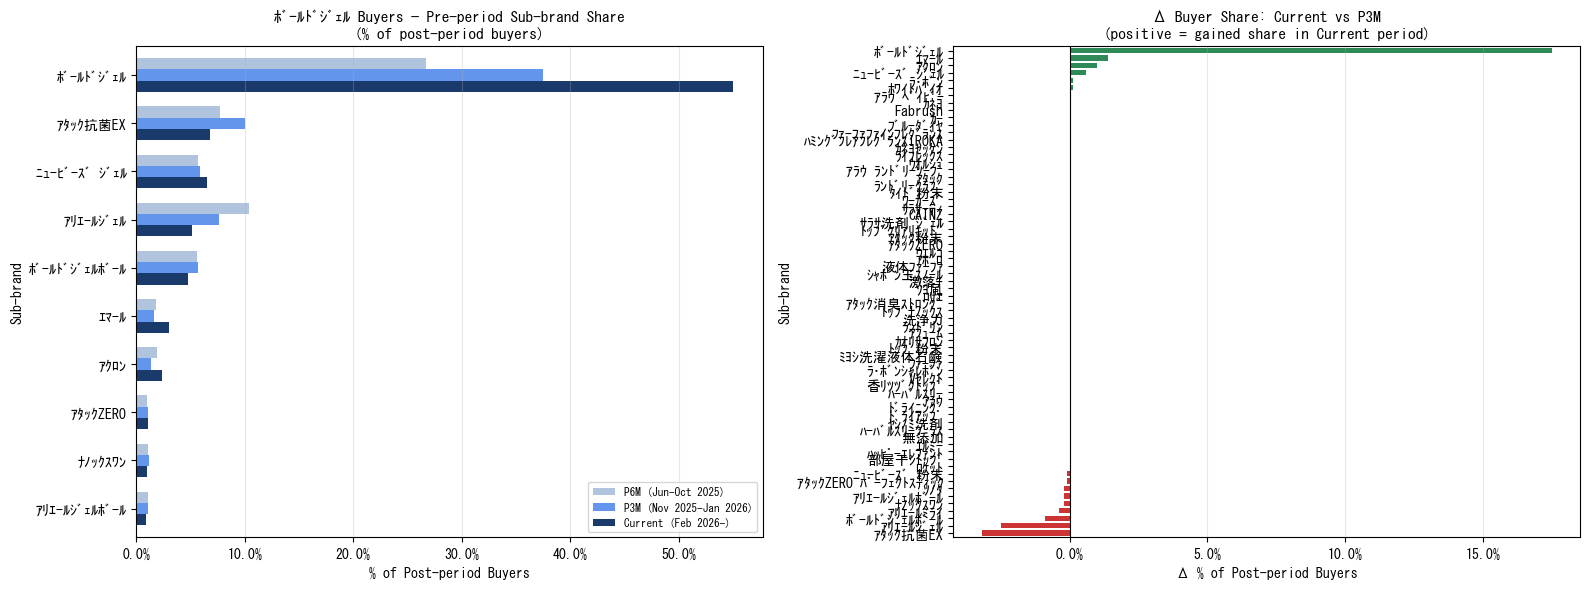

Chart saved: bold_gel_sov_chart.png


In [23]:
# ── Chart 1: Top-10 sub-brands by pct_of_post_buyers across periods ───────
top10_brands = (
    comparison_df[
        comparison_df['sub_brand'] != 'New to Category'
    ]
    .nlargest(10, 'pct_buyers_Current')['sub_brand']
    .tolist()
)

plot_df = comparison_df[comparison_df['sub_brand'].isin(top10_brands)].set_index('sub_brand')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# - Left: buyer share bar chart
ax1 = axes[0]
cols_buyers = ['pct_buyers_P6M', 'pct_buyers_P3M', 'pct_buyers_Current']
labels_p    = ['P6M (Jun-Oct 2025)', 'P3M (Nov 2025-Jan 2026)', 'Current (Feb 2026-)']
plot_df[cols_buyers].plot(
    kind='barh', ax=ax1, width=0.7,
    color=['#b0c4de', '#6495ed', '#1a3a6b']
)
ax1.set_title(f'{TARGET_SUB_BRAND} Buyers — Pre-period Sub-brand Share\n(% of post-period buyers)', fontsize=11)
ax1.set_xlabel('% of Post-period Buyers')
ax1.set_ylabel('Sub-brand')
ax1.legend(labels_p, loc='lower right', fontsize=8)
ax1.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
ax1.invert_yaxis()
ax1.grid(axis='x', alpha=0.3)

# - Right: delta (Current vs P3M) sorted by magnitude
ax2 = axes[1]
delta_df = (
    comparison_df[
        comparison_df['sub_brand'] != 'New to Category'
    ][['sub_brand', 'Δ_buyers_vs_P3M']]
    .set_index('sub_brand')
    .sort_values('Δ_buyers_vs_P3M')
)
colors = ['#cc3333' if v < 0 else '#2e8b57' for v in delta_df['Δ_buyers_vs_P3M']]
delta_df['Δ_buyers_vs_P3M'].plot(kind='barh', ax=ax2, color=colors, width=0.7)
ax2.axvline(0, color='black', linewidth=0.8)
ax2.set_title(f'Δ Buyer Share: Current vs P3M\n(positive = gained share in Current period)', fontsize=11)
ax2.set_xlabel('Δ % of Post-period Buyers')
ax2.set_ylabel('Sub-brand')
ax2.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('bold_gel_sov_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved: bold_gel_sov_chart.png')

---
## 9. Export Results to Excel

In [24]:
export_filename = f'bold_gel_sov_{datetime.now().strftime("%Y%m%d")}.xlsx'

# Summary info
summary_rows = []
for period_name, dates in PERIODS.items():
    tpb = dq_results[period_name]['total_post_buyers']
    summary_rows.append({
        'Period'            : period_name,
        'Post Start'        : dates['post_start'],
        'Post End'          : dates['post_end'],
        'Pre Start'         : dates['pre_start'],
        'Pre End'           : dates['pre_end'],
        'Total Post Buyers' : tpb,
    })
df_summary = pd.DataFrame(summary_rows)

with pd.ExcelWriter(export_filename, engine='openpyxl') as writer:
    df_summary.to_excel(writer, sheet_name='Summary', index=False)

    display_cols = ['brand', 'sub_brand', 'SoV_ID', 'pct_of_post_buyers', 'SoV_Value', 'pct_of_value', 'SoV_Unit', 'pct_of_units']
    for period_name in PERIODS:
        sov_tables[period_name][display_cols].to_excel(
            writer, sheet_name=f'{period_name}_SoV', index=False
        )

    comparison_df.to_excel(writer, sheet_name='Period_Comparison', index=False)

print(f'✅ Export complete: {export_filename}')
print(f'   Sheets: Summary, Current_SoV, P3M_SoV, P6M_SoV, Period_Comparison')

✅ Export complete: bold_gel_sov_20260218.xlsx
   Sheets: Summary, Current_SoV, P3M_SoV, P6M_SoV, Period_Comparison


---
## 10. Interpretation Guide

**How to read the results:**

| Metric | Meaning |
|---|---|
| `pct_of_post_buyers` | % of ﾎﾞｰﾙﾄﾞｼﾞｪﾙ buyers who also bought this sub-brand in the pre-period. Can exceed 100% total (multi-brand shoppers). |
| `pct_of_value` | Value share among matched pre-period purchases only (sums to ~100%). |
| `Δ_buyers_vs_P3M` (+) | More Current buyers previously purchased this sub-brand → this brand is a stronger source for ﾎﾞｰﾙﾄﾞｼﾞｪﾙ. |
| `Δ_buyers_vs_P3M` (−) | Fewer Current buyers came from this brand → pricing may have pulled shoppers away from this competitor. |
| `New to Category` row | Post-period buyers with **no** laundry detergent purchase in the pre-period. |

**Pricing success indicator:**  
If `Δ_buyers_vs_P3M` for a target competitor is **negative** (e.g., ﾦﾐ, ﾅﾉｯｸｽ, etc.), it means that brand is contributing fewer pre-period shoppers to ﾎﾞｰﾙﾄﾞｼﾞｪﾙ buyers in the Current period — suggesting ﾎﾞｰﾙﾄﾞｼﾞｪﾙ retained those shoppers without them switching elsewhere first.